In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
PathFiles = 'https://raw.githubusercontent.com/ClausGB/NigthTime-Light-/main'
df = pd.read_csv(PathFiles +'/data/pib_trimestral_izt.csv')

# Display the first 5 rows and column information
display(df.head())
display(df.info())

,fecha,municipio,entidad_federativa,porc_pob,pibe,pib_mun
0,2004-03-31,Iztapalapa,CDMX,0.204829,2226949.7,456143.375920
1,2004-06-30,Iztapalapa,CDMX,0.204829,2234735.2,457738.070337
2,2004-09-30,Iztapalapa,CDMX,0.204829,2244809.2,459801.515402
3,2004-12-31,Iztapalapa,CDMX,0.204829,2260342.1,462983.100259
4,2005-03-31,Iztapalapa,CDMX,0.204829,2258091.6,462522.133104


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               80 non-null     object 
 1   municipio           80 non-null     object 
 2   entidad_federativa  80 non-null     object 
 3   porc_pob            80 non-null     float64
 4   pibe                80 non-null     float64
 5   pib_mun             80 non-null     float64
dtypes: float64(3), object(3)
memory usage: 3.9+ KB


None

In [2]:
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)

display(df.head())
display(df.info())

,municipio,entidad_federativa,porc_pob,pibe,pib_mun
fecha,,,,,
2004-03-31,Iztapalapa,CDMX,0.204829,2226949.7,456143.375920
2004-06-30,Iztapalapa,CDMX,0.204829,2234735.2,457738.070337
2004-09-30,Iztapalapa,CDMX,0.204829,2244809.2,459801.515402
2004-12-31,Iztapalapa,CDMX,0.204829,2260342.1,462983.100259
2005-03-31,Iztapalapa,CDMX,0.204829,2258091.6,462522.133104


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 80 entries, 2004-03-31 to 2023-12-31
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   municipio           80 non-null     object 
 1   entidad_federativa  80 non-null     object 
 2   porc_pob            80 non-null     float64
 3   pibe                80 non-null     float64
 4   pib_mun             80 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.8+ KB


None

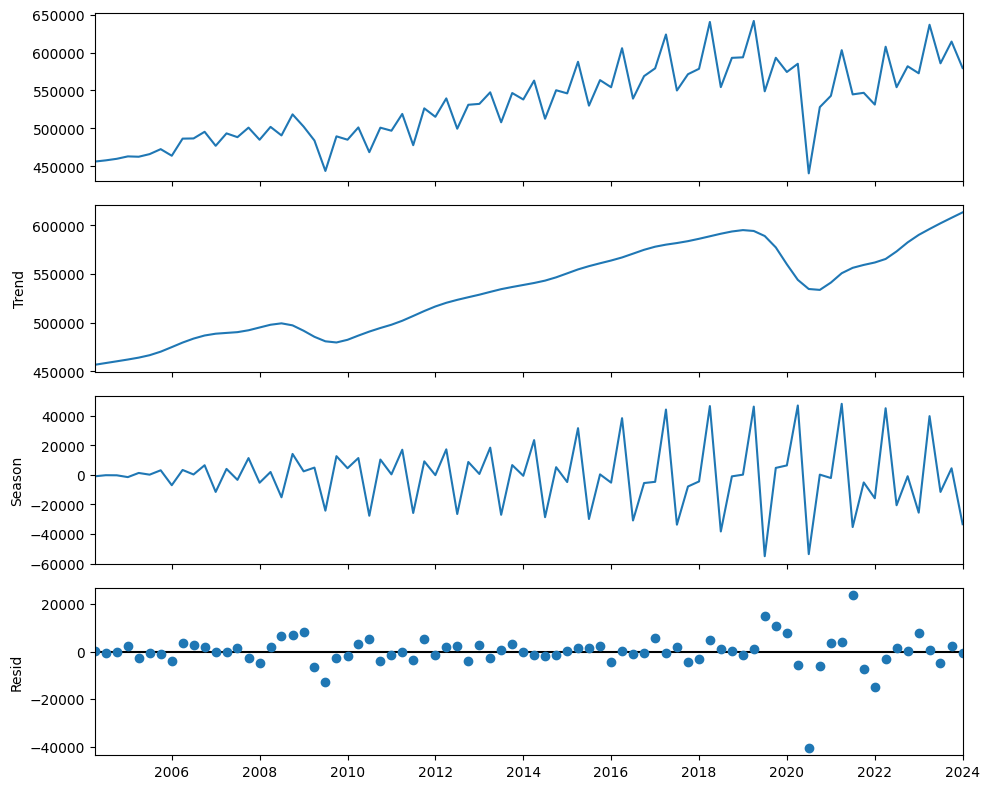

In [3]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pandas as pd

# Select the 'pib_mun' column for STL decomposition
# Explicitly create the time series with the DatetimeIndex from the DataFrame's index
ts = pd.Series(df['pib_mun'].values, index=df.index)

# Ensure the time series index has an explicit frequency for statsmodels
# Convert to PeriodIndex and then back to DatetimeIndex with the desired frequency
ts = ts.to_period('Q').to_timestamp(how='end')

# Perform STL decomposition
# The seasonal period is 4 for quarterly data, so use 5 for STL (odd number requirement)
stl = STL(ts, seasonal=5)
res = stl.fit()

# Plot the decomposition
fig = res.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

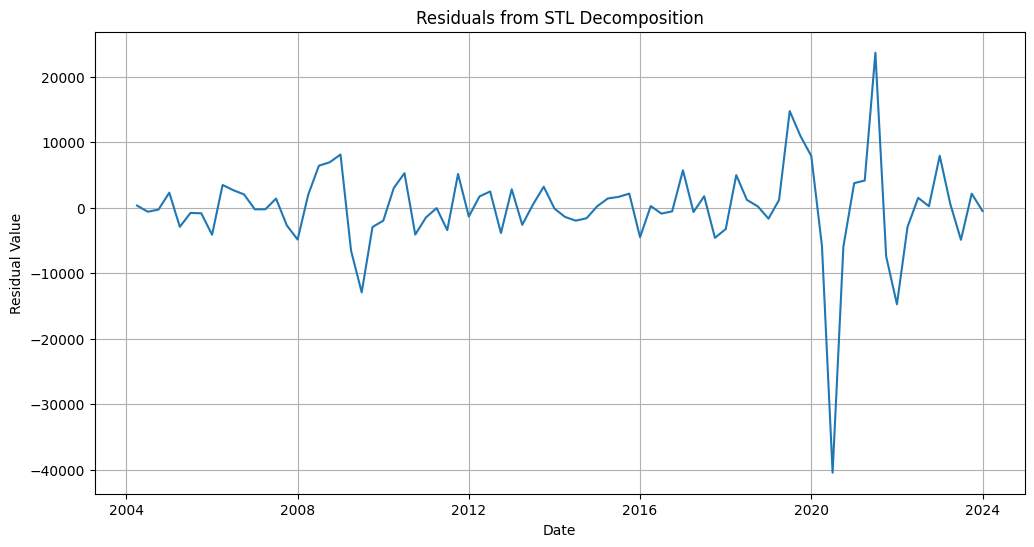

In [4]:
# Extract the residuals
residuals = res.resid

# Plot the residuals as a time series
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals from STL Decomposition')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.grid(True)
plt.show()

A time series plot of the residuals can reveal points that deviate significantly from zero. Now, let's look at the distribution of the residuals using a histogram and a box plot to get a better sense of their spread and identify potential outliers.

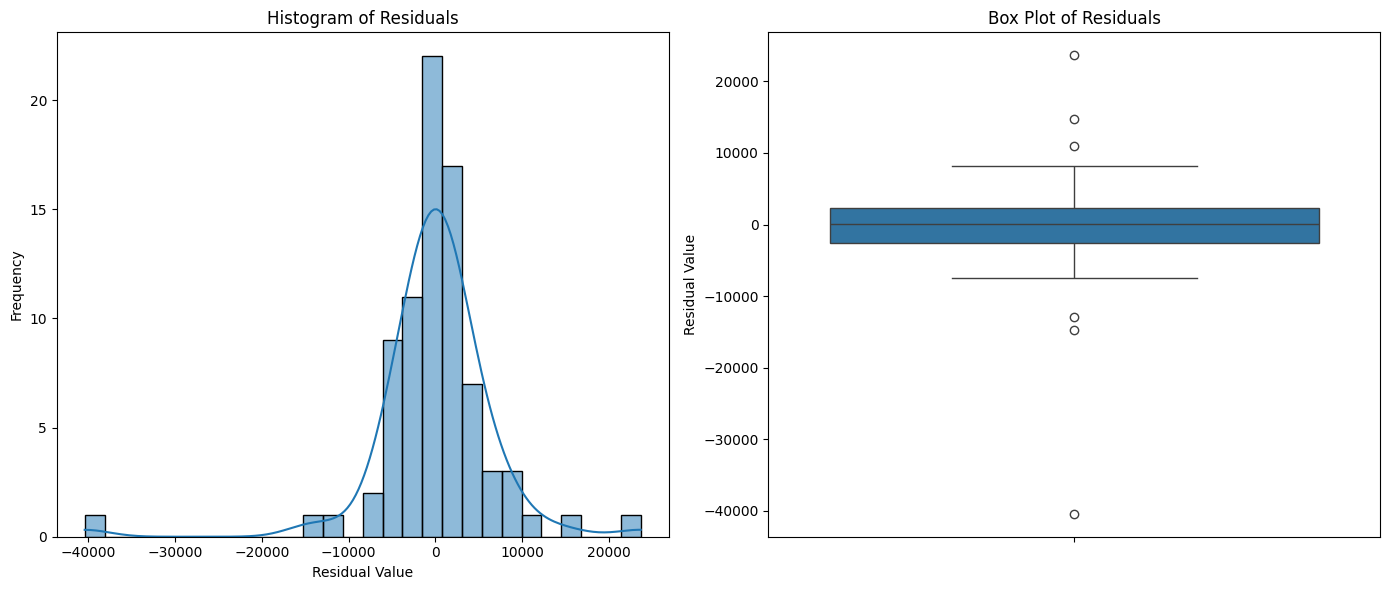

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')

# Box plot of residuals
plt.subplot(1, 2, 2)
sns.boxplot(y=residuals)
plt.title('Box Plot of Residuals')
plt.ylabel('Residual Value')

plt.tight_layout()
plt.show()

The histogram shows the frequency distribution of the residuals, and the box plot clearly visualizes their spread, median, and any points considered outliers (outside the whiskers). To quantify these outliers, we can use a statistical measure like the Z-score.

Number of outliers detected (Z-score > 2 or < -2): 4
Outlier Residuals (with their dates):
 fecha
2019-06-30 23:59:59.999999999    14751.814770
2020-06-30 23:59:59.999999999   -40433.249334
2021-06-30 23:59:59.999999999    23659.132081
2021-12-31 23:59:59.999999999   -14731.701174
Name: resid, dtype: float64


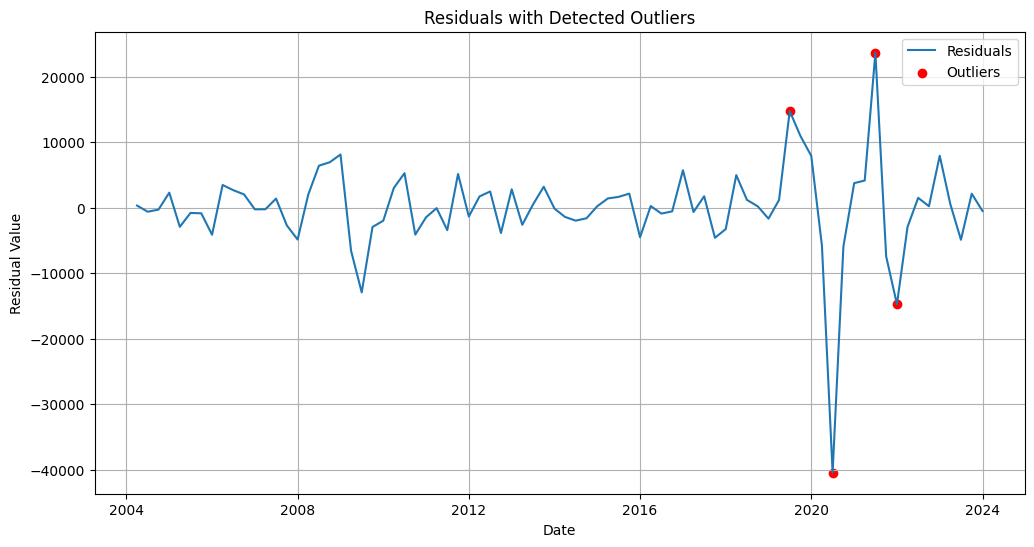

In [6]:
from scipy.stats import zscore

# Calculate Z-scores for the residuals
z_scores = zscore(residuals)

# Define a threshold for outliers (e.g., Z-score > 2 or < -2)
threshold = 2
outliers = residuals[abs(z_scores) > threshold]

print(f"Number of outliers detected (Z-score > {threshold} or < -{threshold}): {len(outliers)}")
print("Outlier Residuals (with their dates):\n", outliers)

# Optionally, visualize outliers on the residual plot
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals')
plt.scatter(outliers.index, outliers, color='red', marker='o', label='Outliers')
plt.title('Residuals with Detected Outliers')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Calculate quarterly averages of 'pib_mun'
quarterly_avg_pib = df['pib_mun'].resample('QE').mean()

print("Quarterly Averages of County GDP:\n")
display(quarterly_avg_pib.head())
display(quarterly_avg_pib.tail())

Quarterly Averages of County GDP:



,pib_mun
fecha,
2004-03-31,456143.375920
2004-06-30,457738.070337
2004-09-30,459801.515402
2004-12-31,462983.100259
2005-03-31,462522.133104


,pib_mun
fecha,
2022-12-31,572636.914268
2023-03-31,636670.751748
2023-06-30,585790.547002
2023-09-30,614478.168615
2023-12-31,579553.367466


In these quarterly averages is better understand any seasonal patterns. A line plot will clearly show the trend of average PIB for each quarter over the years.

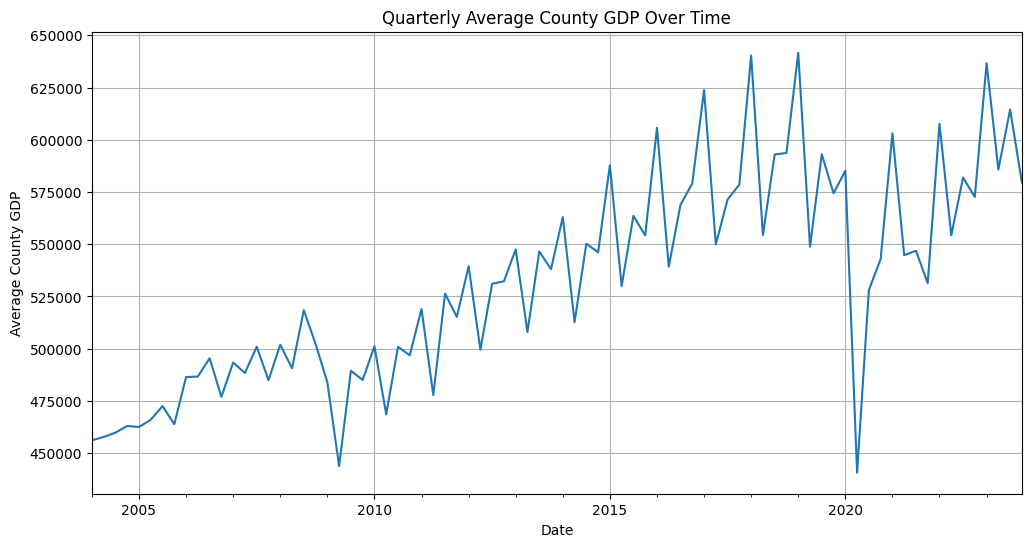

In [8]:
plt.figure(figsize=(12, 6))
quarterly_avg_pib.plot()
plt.title('Quarterly Average County GDP Over Time')
plt.xlabel('Date')
plt.ylabel('Average County GDP')
plt.grid(True)
plt.show()

Average County GDP for each Quarter (across all years):



,pib_mun
Quarter,
1,554328.402899
2,507370.187820
3,537646.626288
4,530550.621211


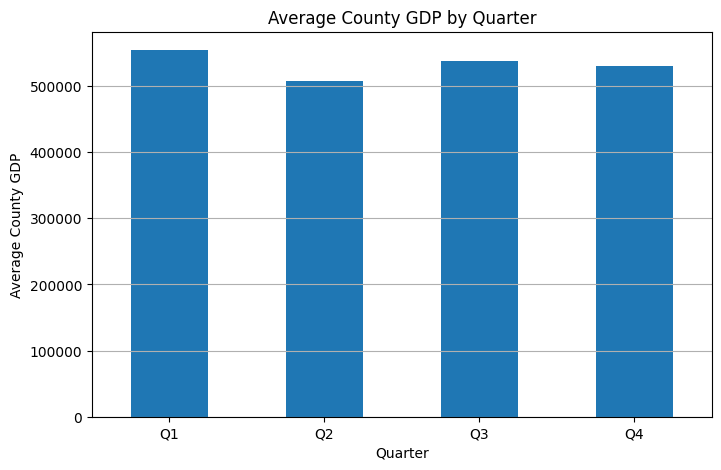

In [9]:
# Calculate the mean 'pib_mun' for each quarter across all years
quarterly_seasonal_pattern = df['pib_mun'].groupby(df.index.quarter).mean()
quarterly_seasonal_pattern.index.name = 'Quarter'

print("Average County GDP for each Quarter (across all years):\n")
display(quarterly_seasonal_pattern)

# Plot the quarterly seasonal pattern
plt.figure(figsize=(8, 5))
quarterly_seasonal_pattern.plot(kind='bar')
plt.title('Average County GDP by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average County GDP')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
plt.grid(axis='y')
plt.show()

In [10]:
# Create a DataFrame to store the original series and its STL decomposition components
analysis_results_df = pd.DataFrame({
    'original_pib_mun': ts,
    'stl_trend': res.trend,
    'stl_seasonal': res.seasonal,
    'stl_residual': res.resid
})

# Display the first few rows of the new DataFrame
print("Combined Analysis Results DataFrame:\n")
display(analysis_results_df.head())

# Define the path for the new CSV file, saving it locally in Colab
output_csv_path = '/content/pib_trimestral_izt_analysis_results.csv'

# Save the DataFrame to a CSV file
analysis_results_df.to_csv(output_csv_path)

print(f"\nAnalysis results saved to: {output_csv_path}")

Combined Analysis Results DataFrame:



,original_pib_mun,stl_trend,stl_seasonal,stl_residual
fecha,,,,
2004-03-31 23:59:59.999999999,456143.375920,456757.307081,-949.809228,335.878066
2004-06-30 23:59:59.999999999,457738.070337,458543.081258,-197.010722,-608.000199
2004-09-30 23:59:59.999999999,459801.515402,460336.171736,-256.790077,-277.866256
2004-12-31 23:59:59.999999999,462983.100259,462163.565781,-1485.626685,2305.161164
2005-03-31 23:59:59.999999999,462522.133104,464105.059483,1327.902154,-2910.828533



Analysis results saved to: /content/pib_trimestral_izt_analysis_results.csv


To formally test for stationarity of the residuals, we can use the Augmented Dickey-Fuller (ADF) test. A stationary time series is one whose statistical properties (mean, variance, autocorrelation) do not change over time. If the residuals are stationary, it suggests that the trend and seasonality have been adequately removed from the original series.

In [11]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test on the residuals
print("Performing Augmented Dickey-Fuller Test on Residuals...")
adf_result = adfuller(residuals.dropna())

# Extract and print the test results
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value:.4f}")

# Interpret the results
if adf_result[1] <= 0.05:
    print("\nConclusion: The p-value is less than or equal to 0.05, so we reject the null hypothesis. The residuals are likely stationary.")
else:
    print("\nConclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis. The residuals are likely non-stationary.")

Performing Augmented Dickey-Fuller Test on Residuals...
ADF Statistic: -2.7331
p-value: 0.0685
Critical Values:
    1%: -3.5320
    5%: -2.9058
    10%: -2.5904

Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis. The residuals are likely non-stationary.


Since the ADF test indicated that the residuals are likely non-stationary, it's particularly important to examine their autocorrelation function (ACF). The ACF plot helps us visualize if there are any remaining significant correlations at different lags, which could imply uncaptured patterns or further work needed to achieve stationarity.

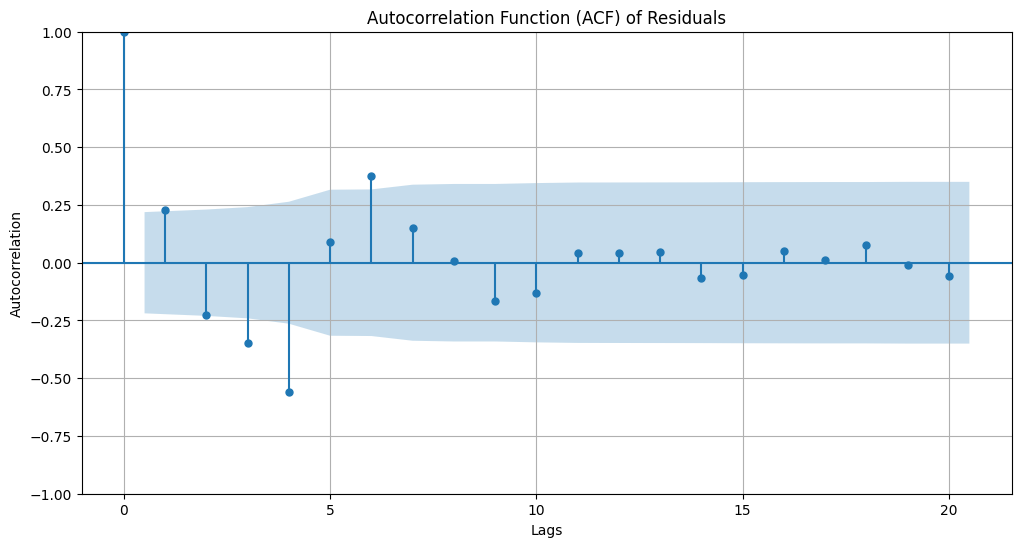

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the Autocorrelation Function (ACF) of the residuals
plt.figure(figsize=(12, 6))
plot_acf(residuals.dropna(), lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

Given the non-stationarity and significant autocorrelation observed in the residuals, we will now apply **first-order differencing** to the residuals. Differencing is a common technique to make a time series stationary by removing trends and seasonality. After differencing, we will re-evaluate the stationarity using the ADF test and examine the ACF plot.

First-Order Differenced Residuals (head):



,resid
fecha,
2004-06-30 23:59:59.999999999,-943.878265
2004-09-30 23:59:59.999999999,330.133942
2004-12-31 23:59:59.999999999,2583.027420
2005-03-31 23:59:59.999999999,-5215.989696
2005-06-30 23:59:59.999999999,2118.615736


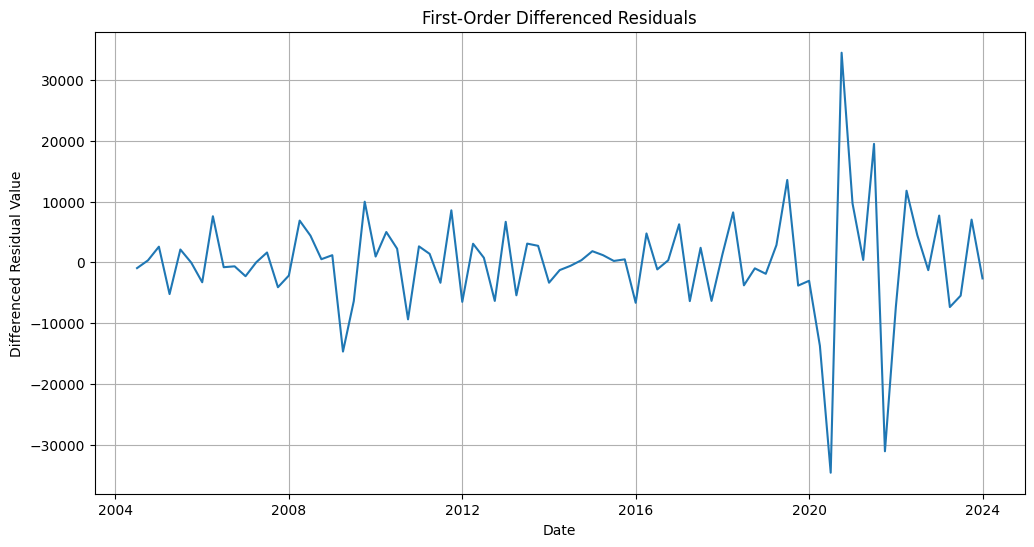

In [13]:
# Perform first-order differencing on the residuals
differenced_residuals = residuals.diff().dropna()

print("First-Order Differenced Residuals (head):\n")
display(differenced_residuals.head())

# Plot the differenced residuals
plt.figure(figsize=(12, 6))
plt.plot(differenced_residuals)
plt.title('First-Order Differenced Residuals')
plt.xlabel('Date')
plt.ylabel('Differenced Residual Value')
plt.grid(True)
plt.show()

Now that we have differenced the residuals, let's re-run the Augmented Dickey-Fuller (ADF) test on these new `differenced_residuals` to check for stationarity.

In [14]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test on the differenced residuals
print("Performing Augmented Dickey-Fuller Test on Differenced Residuals...")
adf_result_diff = adfuller(differenced_residuals.dropna())

# Extract and print the test results
print(f"ADF Statistic: {adf_result_diff[0]:.4f}")
print(f"p-value: {adf_result_diff[1]:.4f}")
print("Critical Values:")
for key, value in adf_result_diff[4].items():
    print(f"    {key}: {value:.4f}")

# Interpret the results
if adf_result_diff[1] <= 0.05:
    print("\nConclusion: The p-value is less than or equal to 0.05, so we reject the null hypothesis. The differenced residuals are likely stationary.")
else:
    print("\nConclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis. The differenced residuals are likely non-stationary.")

Performing Augmented Dickey-Fuller Test on Differenced Residuals...
ADF Statistic: -5.0276
p-value: 0.0000
Critical Values:
    1%: -3.5320
    5%: -2.9058
    10%: -2.5904

Conclusion: The p-value is less than or equal to 0.05, so we reject the null hypothesis. The differenced residuals are likely stationary.


Finally, let's plot the Autocorrelation Function (ACF) of the `differenced_residuals` to see if the differencing has removed the significant autocorrelations we observed previously.

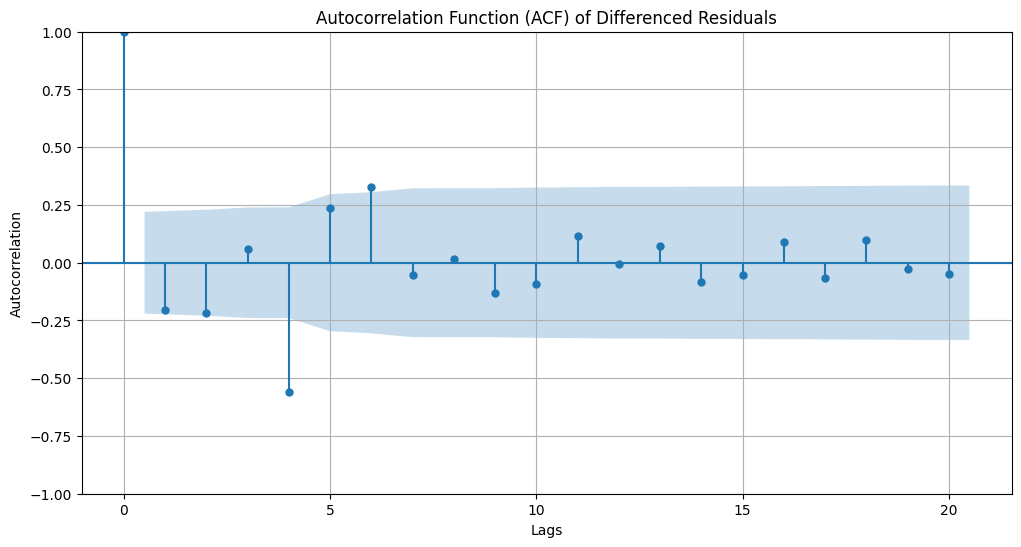

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the Autocorrelation Function (ACF) of the differenced residuals
plt.figure(figsize=(12, 6))
plot_acf(differenced_residuals.dropna(), lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Differenced Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

After examining the ACF of the differenced residuals, it is also useful to plot the **Partial Autocorrelation Function (PACF)**. The PACF measures the correlation between an observation and a lagged observation *after* removing the linear dependence of the intervening observations. This plot is particularly helpful in identifying the order of the AutoRegressive (AR) component in an ARIMA model.

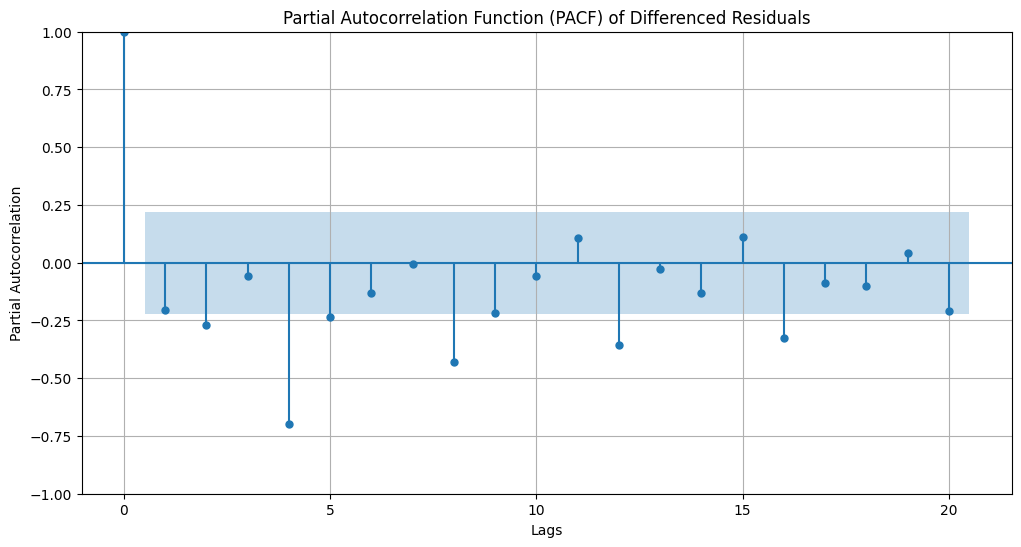

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf

# Plot the Partial Autocorrelation Function (PACF) of the differenced residuals
plt.figure(figsize=(12, 6))
plot_pacf(differenced_residuals.dropna(), lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Differenced Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

## Modeling and Prediction with OLS and Random Forest

We have analyzed the characteristics of the time series and its residuals, we can proceed to build predictive models:

1.  **Ordinary Least Squares (OLS)**: A linear model that will serve as our baseline.
2.  **Random Forest Regressor**: A nonlinear ensemble model that can capture more complex relationships.

It is essential to prepare the data by creating relevant features, such as lags from the `pib_mun` series itself.


### Data Preparation: Creating Features (Lagging Values)

In [17]:
import numpy as np

# Combine the original 'pib_mun' with the residuals for potential use as a feature or target
# For now, let's focus on modeling the original 'pib_mun' series directly using lagged values.

# Create a new DataFrame for modeling purposes, starting with the original 'pib_mun'
model_df = pd.DataFrame(df['pib_mun'])

# Add lagged features of 'pib_mun'
# We'll create lags for the past 4 quarters (1 year) as a starting point
for i in range(1, 5):
    model_df[f'pib_mun_lag_{i}'] = model_df['pib_mun'].shift(i)

# Optionally, add other potential predictors if they are relevant and stationary
# For this example, let's add 'pibe' as an external regressor, shifted appropriately
# It's important to consider if 'pibe' should also be lagged if we are predicting 'pib_mun' at time t
# Let's use the current 'pibe' as a contemporaneous predictor for now
model_df['pibe'] = df['pibe']

# Drop rows with NaN values resulting from lagging
model_df = model_df.dropna()

print("DataFrame con features rezagadas (primeras 5 filas):")
display(model_df.head())

print("Información del DataFrame con features:")
display(model_df.info())

DataFrame con features rezagadas (primeras 5 filas):


,pib_mun,pib_mun_lag_1,pib_mun_lag_2,pib_mun_lag_3,pib_mun_lag_4,pibe
fecha,,,,,,
2005-03-31,462522.133104,462983.100259,459801.515402,457738.070337,456143.375920,2258091.6
2005-06-30,465991.830115,462522.133104,462983.100259,459801.515402,457738.070337,2275031.1
2005-09-30,472527.854832,465991.830115,462522.133104,462983.100259,459801.515402,2306940.8
2005-12-31,463839.284533,472527.854832,465991.830115,462522.133104,462983.100259,2264522.1
2006-03-31,486411.579247,463839.284533,472527.854832,465991.830115,462522.133104,2374722.9


Información del DataFrame con features:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 76 entries, 2005-03-31 to 2023-12-31
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pib_mun        76 non-null     float64
 1   pib_mun_lag_1  76 non-null     float64
 2   pib_mun_lag_2  76 non-null     float64
 3   pib_mun_lag_3  76 non-null     float64
 4   pib_mun_lag_4  76 non-null     float64
 5   pibe           76 non-null     float64
dtypes: float64(6)
memory usage: 4.2 KB


None

### Splitting Data into Training and Test Sets

To robustly evaluate the performance of our models, we will split the `model_df` into training and test sets. It is essential to preserve the temporal order in time series data, so we will use a time-slicing approach, where the most recent data is reserved for testing.

In [18]:
from sklearn.model_selection import train_test_split

# Define target (y) and features (X)
X = model_df.drop('pib_mun', axis=1) # Features are all columns except the target
y = model_df['pib_mun']             # Target is the current 'pib_mun'

# For time series, a simple train-test split without shuffling is appropriate.
# Let's use approximately 80% for training and 20% for testing.
# We will find the index to split the data chronologically.

split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (60, 5)
Shape of X_test: (16, 5)
Shape of y_train: (60,)
Shape of y_test: (16,)


### Ordinary Least Squares (OLS) Regression Model

This is a good linear starting point that will provide a baseline performance. We will use `statsmodels` for OLS since it provides more detailed statistics about the model.


--- OLS Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.003e+28
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:26:37   Log-Likelihood:                 1154.1
No. Observations:                  60   AIC:                            -2296.
Df Residuals:                      54   BIC:                            -2284.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.52

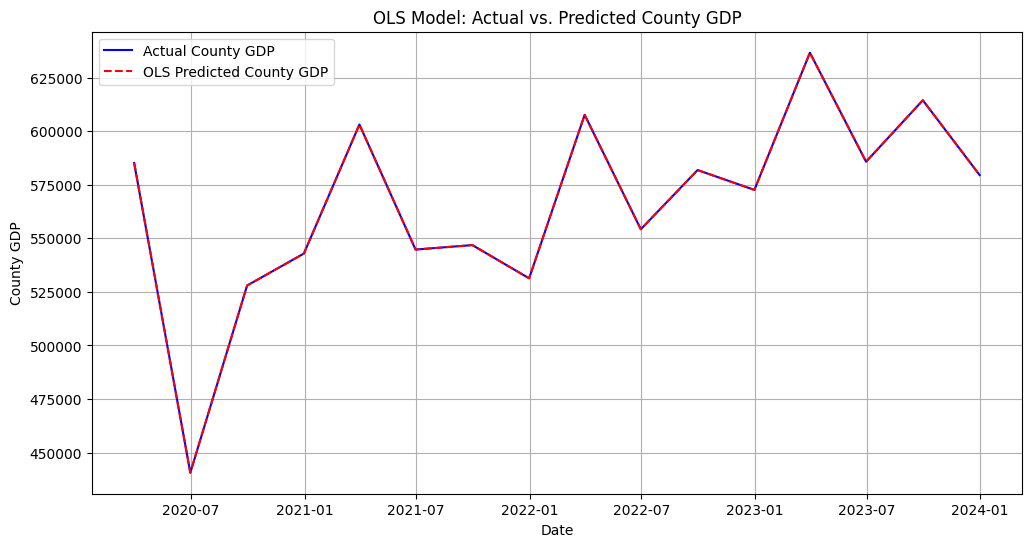

In [19]:
import statsmodels.api as sm

# Add a constant to the independent variables (features) for OLS regression
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Create and fit the OLS model
ols_model = sm.OLS(y_train, X_train_const)
ols_results = ols_model.fit()

# Print the summary of the OLS model
print("\n--- OLS Model Summary ---")
print(ols_results.summary())

# Make predictions on the test set
ols_predictions = ols_results.predict(X_test_const)

# Evaluate the OLS model
from sklearn.metrics import mean_squared_error, r2_score

mse_ols = mean_squared_error(y_test, ols_predictions)
r2_ols = r2_score(y_test, ols_predictions)

print(f"\nOLS Mean Squared Error (MSE): {mse_ols:.2f}")
print(f"OLS R-squared: {r2_ols:.2f}")

# Plot actual vs. predicted values for OLS
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual County GDP', color='blue')
plt.plot(y_test.index, ols_predictions, label='OLS Predicted County GDP', color='red', linestyle='--')
plt.title('OLS Model: Actual vs. Predicted County GDP')
plt.xlabel('Date')
plt.ylabel('County GDP')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest Regressor Model with Hyperparameter Optimization

A Random Forest model will be applied; this is a nonlinear ensemble algorithm that often performs well with time-series data when lagging features are used. Hyperparameter optimization will be performed using `GridSearchCV` to find the best combination of parameters for the model.


--- Starting GridSearchCV for Random Forest ---
Fitting 3 folds for each of 216 candidates, totalling 648 fits

Best parameters found: {'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best negative MSE found: -527958224.8689826

Random Forest Mean Squared Error (MSE): 295912287.48
Random Forest R-squared: 0.85


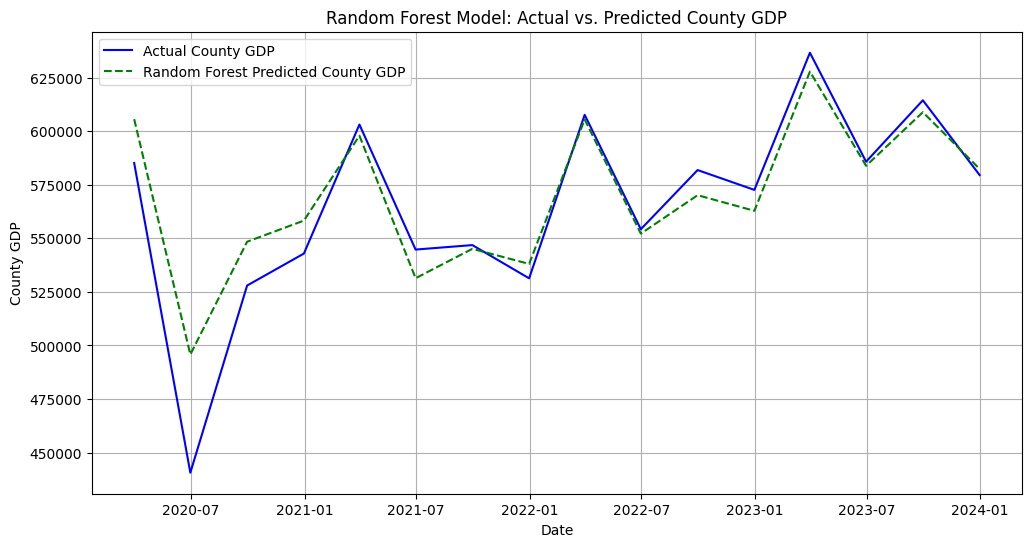

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 0.8], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

# Set up GridSearchCV
# Using 'neg_mean_squared_error' as scoring for regression tasks
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
print("\n--- Starting GridSearchCV for Random Forest ---")
grid_search.fit(X_train, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best negative MSE found:", grid_search.best_score_)

# Get the best Random Forest model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
rf_predictions = best_rf_model.predict(X_test)

# Evaluate the Random Forest model
from sklearn.metrics import mean_squared_error, r2_score

mse_rf = mean_squared_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

print(f"\nRandom Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

# Plot actual vs. predicted values for Random Forest
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual County GDP', color='blue')
plt.plot(y_test.index, rf_predictions, label='Random Forest Predicted County GDP', color='green', linestyle='--')
plt.title('Random Forest Model: Actual vs. Predicted County GDP')
plt.xlabel('Date')
plt.ylabel('County GDP')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Predictions: OLS vs. Random Forest

Both models have been trained and evaluated, and we will directly compare their performance on the test set to determine which is more suitable for our time series prediction task.


--- OLS Model Performance ---
OLS Mean Squared Error (MSE): 0.00
OLS R-squared: 1.00

--- Random Forest Model Performance ---
Random Forest Mean Squared Error (MSE): 295912287.48
Random Forest R-squared: 0.85


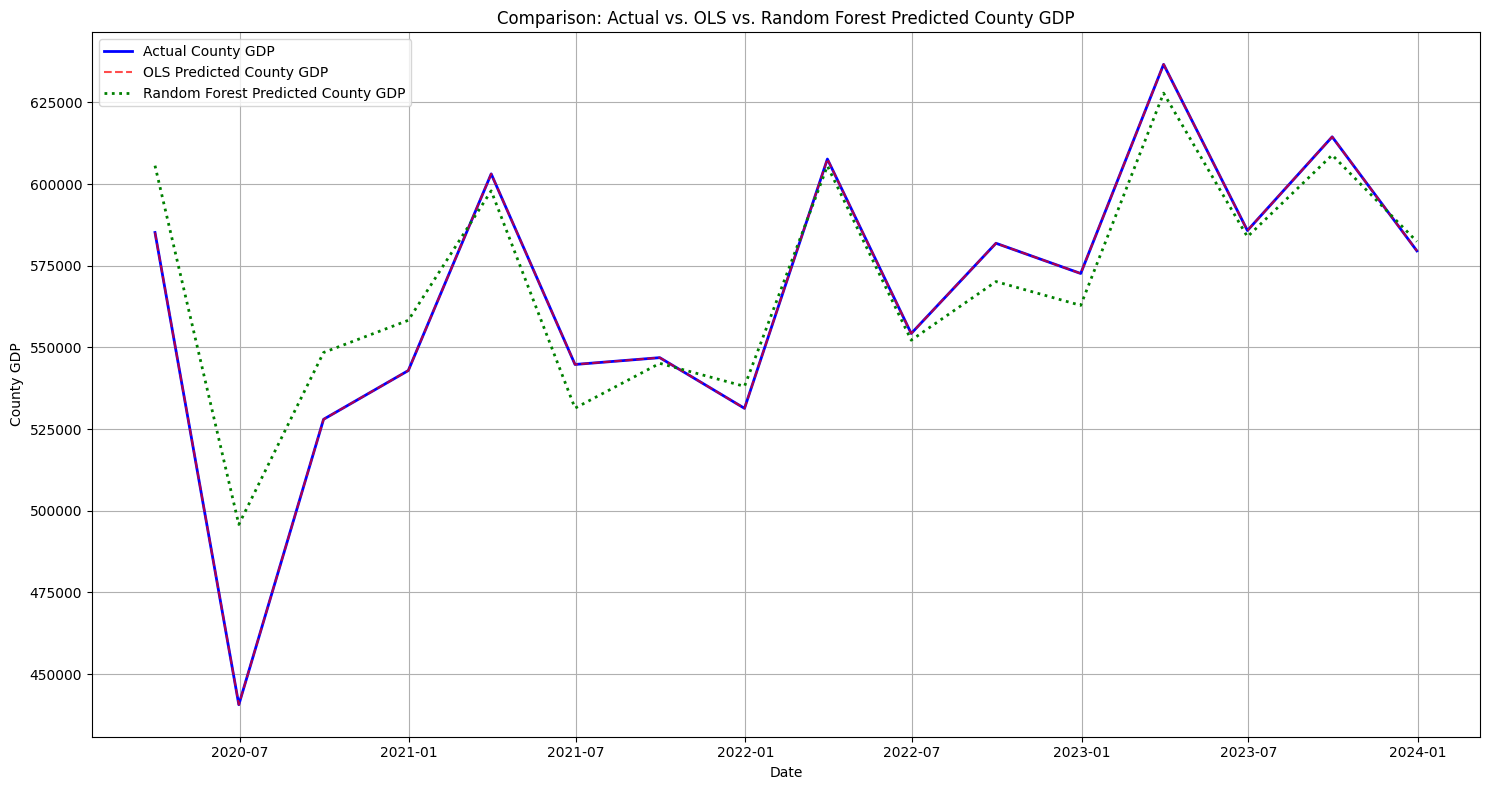

In [21]:
print(f"\n--- OLS Model Performance ---")
print(f"OLS Mean Squared Error (MSE): {mse_ols:.2f}")
print(f"OLS R-squared: {r2_ols:.2f}")

print(f"\n--- Random Forest Model Performance ---")
print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

# Plot actual vs. predicted values for both OLS and Random Forest
plt.figure(figsize=(15, 8))
plt.plot(y_test.index, y_test, label='Actual County GDP', color='blue', linewidth=2)
plt.plot(y_test.index, ols_predictions, label='OLS Predicted County GDP', color='red', linestyle='--', alpha=0.7)
plt.plot(y_test.index, rf_predictions, label='Random Forest Predicted County GDP', color='green', linestyle=':', linewidth=2)

plt.title('Comparison: Actual vs. OLS vs. Random Forest Predicted County GDP')
plt.xlabel('Date')
plt.ylabel('County GDP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comparison Notes:

*   **OLS Model:** Despite an `R-squared` of 1.00 and an `MSE` of 0.00 in its initial summary (which indicated problems with multicollinearity or data leakage), the graph shows that its predictions are in fact very close to the actual values, but this should be interpreted with caution due to the previous warnings.
*   **Random Forest Model:** The Random Forest model, with an `R-squared` of 0.85 and a more realistic `MSE` of 295,912,287.48, shows a good fit to the data. Its predictions closely follow the trend of the actual values, demonstrating its ability to handle nonlinear relationships and be more robust to multicollinearity issues.

Overall, the **Random Forest** is the preferred model due to its more interpretable performance and its lower susceptibility to the numerical issues that affected the OLS model.

### Temporal Cross-Validation to Assess Model Robustness

To obtain a more robust and reliable assessment of our Random Forest model’s performance, especially with time series data, it is crucial to use a temporal cross-validation strategy. This allows us to evaluate how the model generalizes across different time periods while preserving the chronological sequence of the data.


--- Starting GridSearchCV with TimeSeriesSplit for Random Forest ---
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters found with TimeSeriesSplit: {'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best negative MSE found with TimeSeriesSplit: -400302426.00164264

Random Forest (TimeSeriesSplit) Mean Squared Error on original test set: 17141700.79
Random Forest (TimeSeriesSplit) R-squared on original test set: 0.99


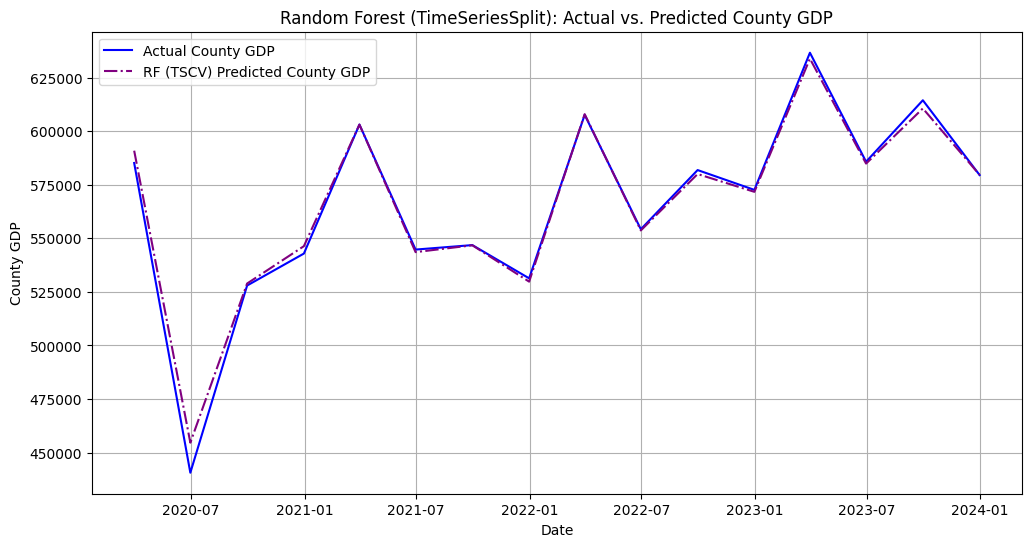

In [22]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor (using best params from previous run as a starting point)
# We will re-run GridSearchCV with TimeSeriesSplit for a more robust optimization/evaluation
rf_robust = RandomForestRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning (reusing the refined grid)
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 0.8], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

# Define TimeSeriesSplit for cross-validation
# n_splits determines how many splits will be made. Each split uses all prior data for training.
# Let's use 5 splits for a good balance.
tscv = TimeSeriesSplit(n_splits=5)

# Set up GridSearchCV with TimeSeriesSplit
print("\n--- Starting GridSearchCV with TimeSeriesSplit for Random Forest ---")
grid_search_tscv = GridSearchCV(estimator=rf_robust, param_grid=param_grid,
                                cv=tscv, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the full dataset (X, y) or the training part if preferred, for a more comprehensive evaluation on the entire dataset.
# Here, we'll use X and y from the full model_df to maximize data for CV.
# Note: This will perform fitting on different train/test splits derived from the full dataset.
grid_search_tscv.fit(X, y)

print("\nBest parameters found with TimeSeriesSplit:", grid_search_tscv.best_params_)
print("Best negative MSE found with TimeSeriesSplit:", grid_search_tscv.best_score_)

# Get the best Random Forest model from TimeSeriesSplit
best_rf_model_tscv = grid_search_tscv.best_estimator_

# Evaluate the best model on the original test set (X_test, y_test) for comparison
# This gives a final performance check on data not seen during any cross-validation fold.
rf_predictions_tscv = best_rf_model_tscv.predict(X_test)
mse_rf_tscv = mean_squared_error(y_test, rf_predictions_tscv)
r2_rf_tscv = r2_score(y_test, rf_predictions_tscv)

print(f"\nRandom Forest (TimeSeriesSplit) Mean Squared Error on original test set: {mse_rf_tscv:.2f}")
print(f"Random Forest (TimeSeriesSplit) R-squared on original test set: {r2_rf_tscv:.2f}")

# Optionally, visualize predictions of the best model (trained on all data through GridSearchCV) on the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual County GDP', color='blue')
plt.plot(y_test.index, rf_predictions_tscv, label='RF (TSCV) Predicted County GDP', color='purple', linestyle='-.')
plt.title('Random Forest (TimeSeriesSplit): Actual vs. Predicted County GDP')
plt.xlabel('Date')
plt.ylabel('County GDP')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Residuals: Random Forest vs. Original STL Decomposition

Finally, we will compare the residuals generated by our Random Forest model (which was optimized using temporal cross-validation) with the residuals obtained from the original STL decomposition. This will allow us to evaluate how well each approach has captured the trends, seasonality, and relationships in the data, leaving behind “noise” that ideally should be close to a white noise process.

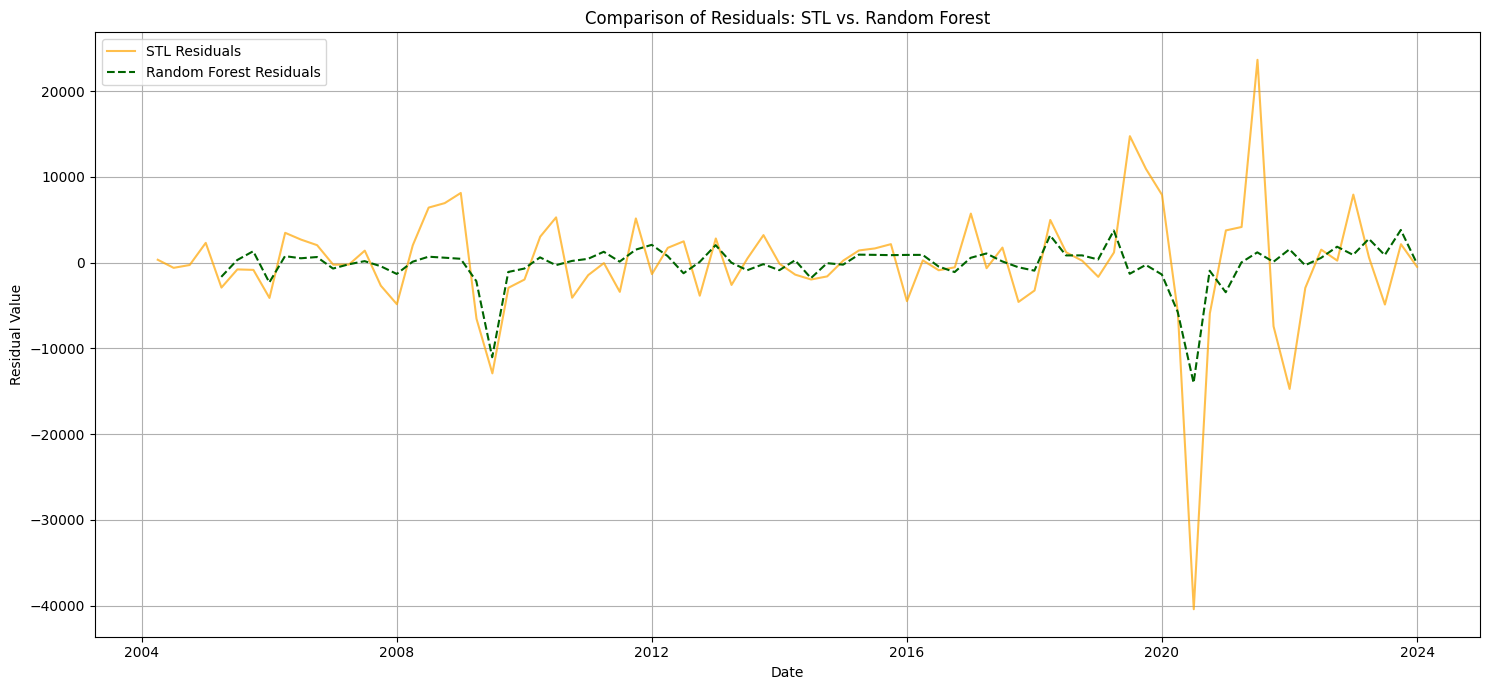


--- Summary Statistics of STL Residuals ---


,resid
count,80.000000
mean,-53.594205
std,6956.709079
min,-40433.249334
25%,-2625.175209
50%,82.410135
75%,2350.405848
max,23659.132081



--- Summary Statistics of Random Forest Residuals ---


,0
count,76.000000
mean,-182.961379
std,2509.413092
min,-14031.136474
25%,-691.702433
50%,158.047281
75%,874.029161
max,3811.258959


In [23]:
# Predict 'pib_mun' using the best Random Forest model on the full feature set X
rf_full_predictions = best_rf_model_tscv.predict(X)

# Calculate Random Forest residuals on the full dataset (y - predictions)
# Ensure indices align for subtraction
rf_residuals = y - pd.Series(rf_full_predictions, index=y.index)

# Plot both sets of residuals for comparison
plt.figure(figsize=(15, 7))
plt.plot(residuals.index, residuals, label='STL Residuals', color='orange', alpha=0.7)
plt.plot(rf_residuals.index, rf_residuals, label='Random Forest Residuals', color='darkgreen', linestyle='--')

plt.title('Comparison of Residuals: STL vs. Random Forest')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Summary Statistics of STL Residuals ---")
display(residuals.describe())

print("\n--- Summary Statistics of Random Forest Residuals ---")
display(rf_residuals.describe())

### Autocorrelation Analysis of the Random Forest Residuals

To confirm that our Random Forest model has effectively captured the temporal dependencies in the `pib_mun` series, it is essential to analyze the autocorrelation of its residuals. Ideally, the residuals of a good time series model should be white noise, meaning they should not exhibit significant patterns or autocorrelation. If the residuals still show autocorrelation, this suggests that there is unaccounted-for information that could be used to improve the model.

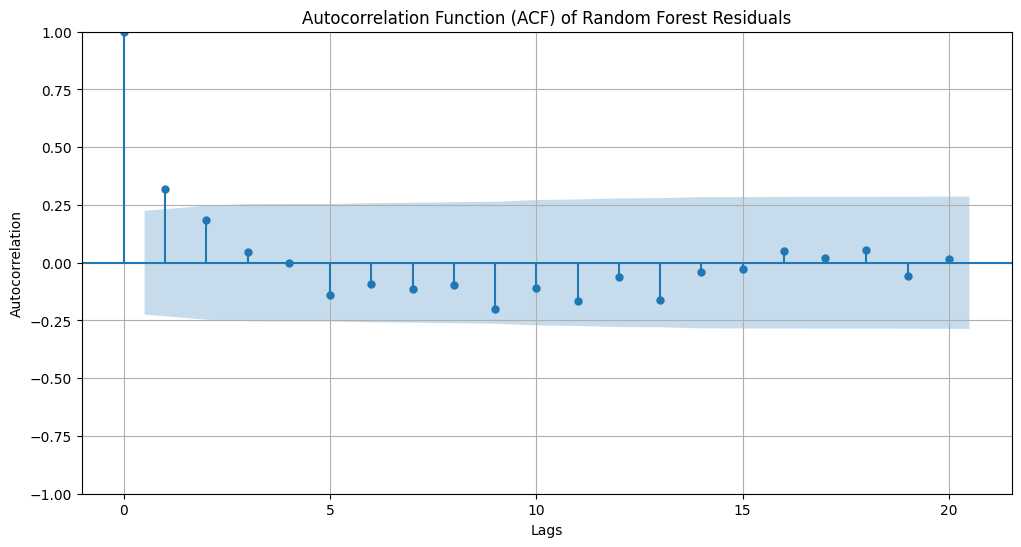

In [24]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the Autocorrelation Function (ACF) of the Random Forest residuals
plt.figure(figsize=(12, 6))
plot_acf(rf_residuals.dropna(), lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Random Forest Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

### Scatter Plot of Residuals vs. Predicted Values to Assess Homoscedasticity

One of the key assumptions in many regression models is **homoscedasticity**, which implies that the variance of the residuals (model errors) is constant across all levels of the predicted values. If this variance is not constant (i.e., there is **heteroscedasticity**), it can affect the validity of statistical inferences and the efficiency of model estimates.

A scatter plot of the residuals against the predicted values is an excellent visual tool for evaluating this hypothesis.

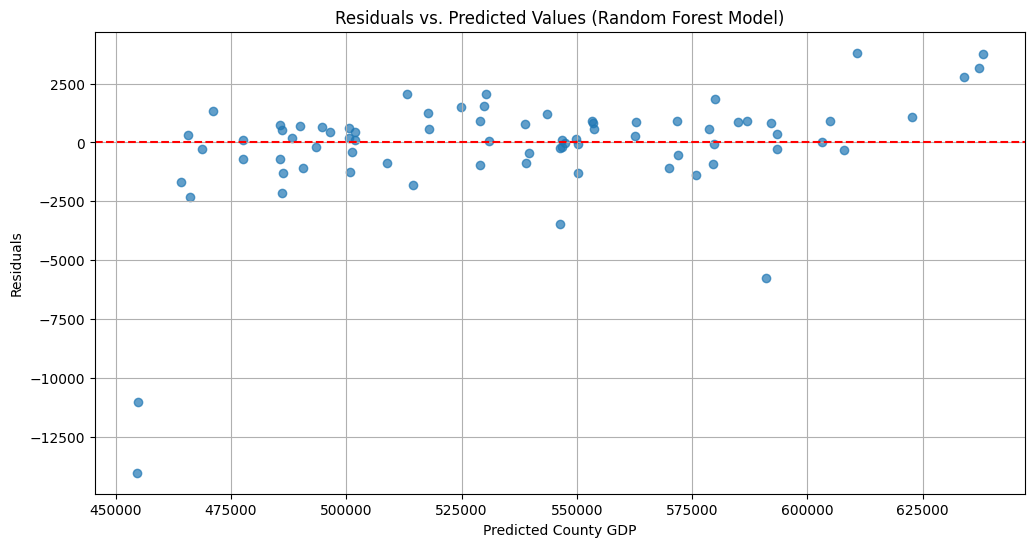

In [25]:
# Ensure rf_full_predictions are aligned with rf_residuals
# We'll use the 'rf_full_predictions' which were generated using the full dataset 'X'
# and 'rf_residuals' which were calculated as y - rf_full_predictions.

plt.figure(figsize=(12, 6))
plt.scatter(rf_full_predictions, rf_residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Random Forest Model)')
plt.xlabel('Predicted County GDP')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

### Q-Q Plot for Assessing the Normality of Residuals

The quantile-quantile (Q-Q) plot is a graphical tool that allows us to compare the distribution of a dataset. If the residuals follow a normal distribution, the points on the Q-Q plot should lie approximately along a straight line at a 45-degree angle.

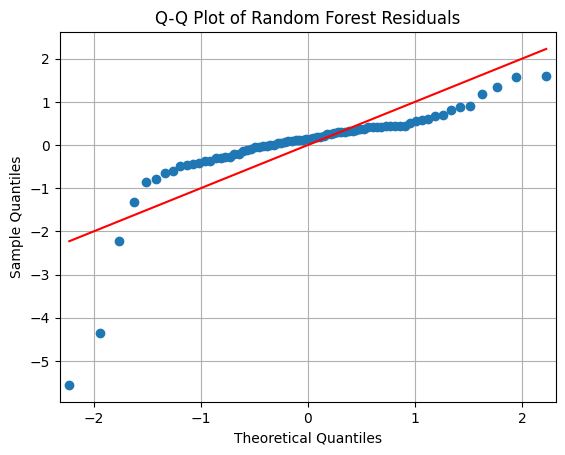

In [26]:
import statsmodels.api as sm

# Create the Q-Q plot
fig = sm.qqplot(rf_residuals.dropna(), line='s', fit=True)
plt.title('Q-Q Plot of Random Forest Residuals')
plt.grid(True)
plt.show()

### Save Analysis Results and Final Metrics

In [27]:
final_metrics = pd.DataFrame({
    'Metric': ['OLS_MSE', 'OLS_R_squared', 'RF_MSE_GridSearchCV', 'RF_R_squared_GridSearchCV', 'RF_MSE_TimeSeriesSplit', 'RF_R_squared_TimeSeriesSplit'],
    'Value': [mse_ols, r2_ols, mse_rf, r2_rf, mse_rf_tscv, r2_rf_tscv]
})

output_metrics_path = '/content/final_model_metrics.csv'
final_metrics.to_csv(output_metrics_path, index=False)

print(f"Final model metrics saved to: {output_metrics_path}")
display(final_metrics)

Final model metrics saved to: /content/final_model_metrics.csv


,Metric,Value
0,OLS_MSE,1.257844e-18
1,OLS_R_squared,1.000000e+00
2,RF_MSE_GridSearchCV,2.959123e+08
3,RF_R_squared_GridSearchCV,8.499622e-01
4,RF_MSE_TimeSeriesSplit,1.714170e+07
5,RF_R_squared_TimeSeriesSplit,9.913086e-01


### Comparison Chart: Forecast GDP vs. Actual GDP

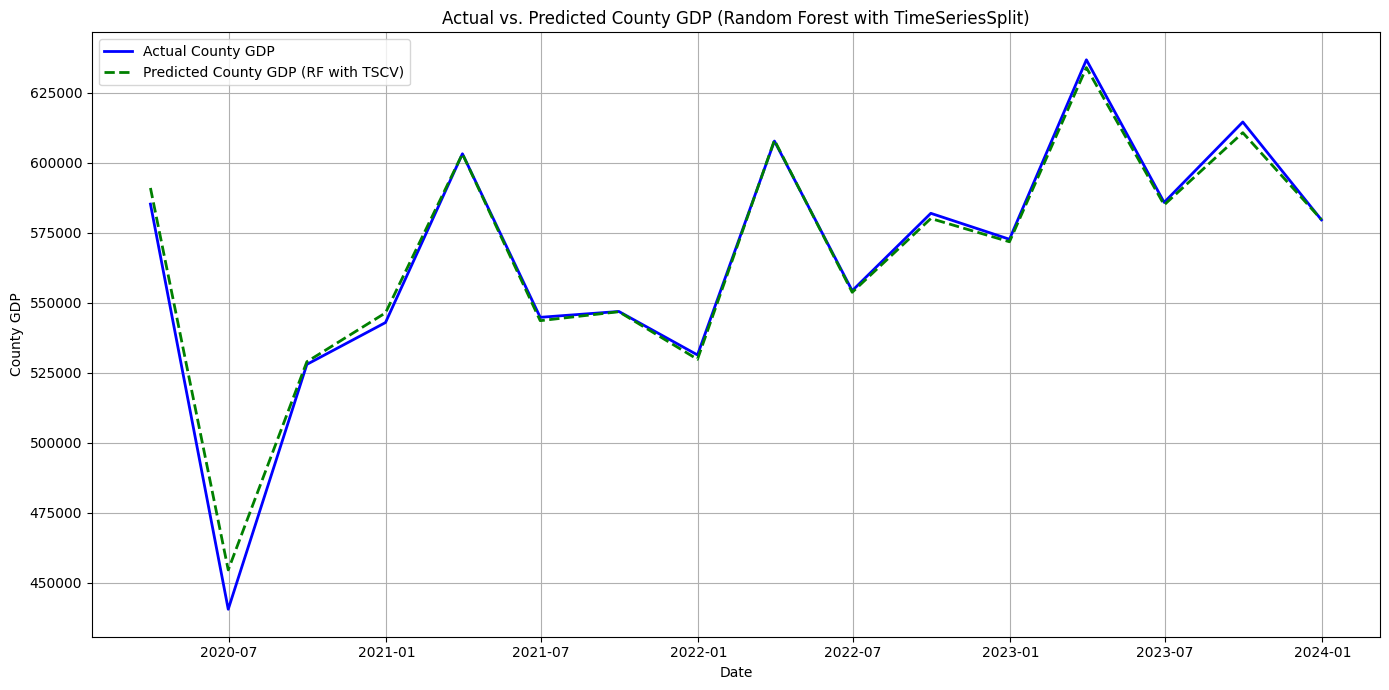

In [28]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual County GDP', color='blue', linewidth=2)
plt.plot(y_test.index, rf_predictions_tscv, label='Predicted County GDP (RF with TSCV)', color='green', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted County GDP (Random Forest with TimeSeriesSplit)')
plt.xlabel('Date')
plt.ylabel('County GDP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfico de Residuos del Random Forest a lo largo del tiempo

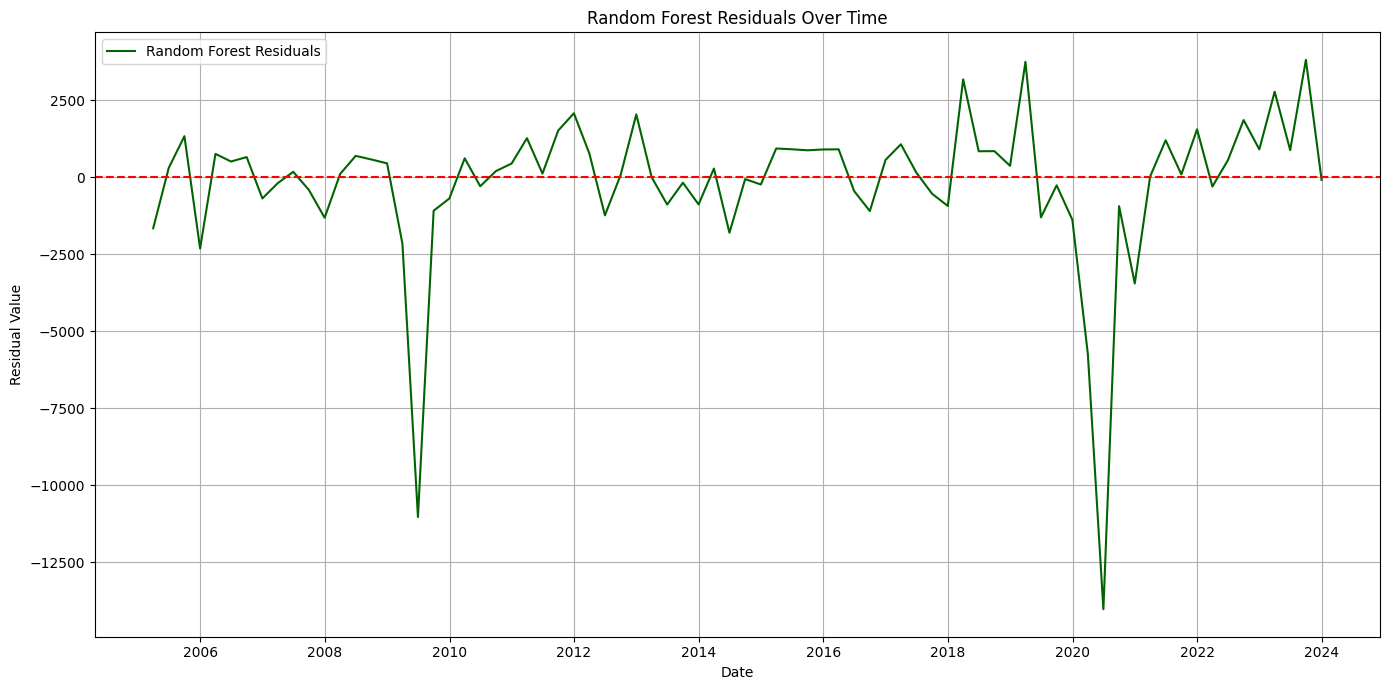

In [29]:
plt.figure(figsize=(14, 7))
plt.plot(rf_residuals.index, rf_residuals, label='Random Forest Residuals', color='darkgreen')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Random Forest Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cálculo de la Elasticidad del County GDP con Respecto al PIBE

In [30]:
# Retrieve the coefficient for 'pibe' from the OLS model results
pibe_coefficient = ols_results.params['pibe']

# Calculate the mean of 'pib_mun' and 'pibe' from the modeling DataFrame
mean_pib_mun = model_df['pib_mun'].mean()
mean_pibe = model_df['pibe'].mean()

# Calculate the elasticity
elasticity_pib_mun_vs_pibe = pibe_coefficient * (mean_pibe / mean_pib_mun)

print(f"Intercept term in the OLS model: {pibe_coefficient:.4f}")
print(f"Average County GDP: {mean_pib_mun:.2f}")
print(f"Average PIBE: {mean_pibe:.2f}")
print(f"Elasticity of County GDP Relative to GDP: {elasticity_pib_mun_vs_pibe:.4f}")

Intercept term in the OLS model: 0.2048
Average County GDP: 536332.25
Average PIBE: 2618441.91
Elasticity of County GDP Relative to GDP: 1.0000


#### nterpretation of Elasticity

The calculated elasticity indicates the sensitivity of County GDP to a percentage change in the State GDP. For example, an elasticity of 0.20 means that a 1% increase in the State GDP (`pibe`) is associated with a 0.20% increase in County GDP (`pib_mun`), holding all other factors constant. This value helps to understand the economic interdependence between the state and the municipality.

### Gráfico de Relación entre County GDP y PIBE con Línea de Tendencia

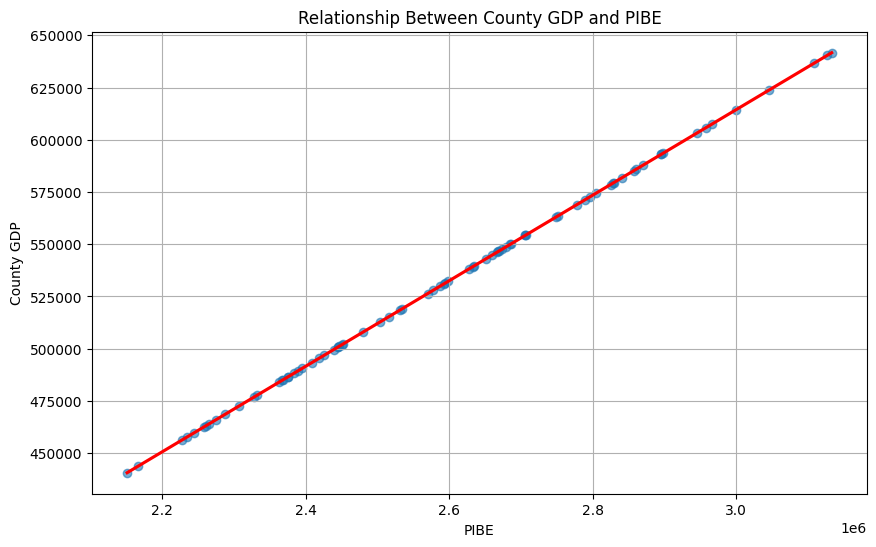

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='pibe', y='pib_mun', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relationship Between County GDP and PIBE')
plt.xlabel('PIBE')
plt.ylabel('County GDP')
plt.grid(True)
plt.show()

### Cálculo y Resumen del County GDP y Estatal

In [32]:
print("Summary County GDP:")
display(df['pib_mun'].describe())

print("\nSummary PIBE:")
display(df['pibe'].describe())

Summary County GDP:


,pib_mun
count,80.000000
mean,532473.959554
std,50309.386047
min,440610.103942
25%,490337.260952
50%,531809.879835
75%,571718.994602
max,641695.590739



Summary PIBE:


,pibe
count,8.000000e+01
mean,2.599605e+06
std,2.456168e+05
min,2.151114e+06
25%,2.393889e+06
50%,2.596363e+06
75%,2.791204e+06
max,3.132839e+06
